# Data Distribution Analysis Guide (Discrete Focus)

## Overview

This notebook will guide you through analyzing discrete data distributions step by step.

We’ll cover:

- Understanding the data type

- Identifying the analytical question

- Calculating descriptive statistics

- Interpreting graphs and results


Each section has a Question → Your Answer → `Compare Answer` toggle. Your answer doesn’t have to be exact — the goal is reasoning, not memorization.

Tip: Use the summary markdown files in the repo for a compact overview of steps and formulas.

1. Understand the Data Type: Continuous or discrete.

2. Identify the Analytical Question: Determine which distribution fits your question.

3. Calculate Descriptive Statistics: Compute and visualize summary statistics.

4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.



---

# Case Study-Customer Complaints:

## You will be guided step-by-step:


### Scenario: A retail company wants to understand the number of customer complaints received per day over the past year. 

#### Question: Which type of distribution might fit this situation?



<details>
  <summary>Hints</summary>
  <p>

We’re counting events.

They occur within a fixed time period (days).

There’s no fixed “maximum number” of complaints possible.</p>
  
</details>

<details> 
<summary>Compare Answer</summary> 

This is a **Poisson distribution**, since we are modeling the **number of events per fixed time interval**. 
</details>

---

## 1. Understand the Data Type

### Step: Determine Whether Your Data is Continuous or Discrete

- **Discrete Data**: Takes on distinct, separate values. Examples include the number of emails received in an hour or the number of customer complaints. Common distributions for discrete data include:
  - **Binomial Distribution**: Used when counting the number of successes in a fixed number of trials.
  - **Poisson Distribution**: Used for modeling the number of events in a fixed interval of time or space.

- **Continuous Data**: Takes on any value within a range. Examples include height, temperature, or time. Common distributions for continuous data include:
  - **Normal Distribution**: Used for data that is symmetrically distributed around the mean.
  - **Exponential Distribution**: Used for modeling the time between events.
  - **Log-Normal Distribution**: Used for data that is normally distributed when logged.

- **Why It Matters**: The type of data determines which probability distribution and statistical methods are appropriate for analysis.



### Question: What type of data are we working with in the case study?



#### Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The data is discrete because it represents the count of customer complaints per day.</p>
  
</details>

---


## 2. Identify the Analytical Question

### Now that you know the data type, the next step is to ask: 
`What exactly do we want to find out from this data?`


Here’s a simple decision guide:

- Counting successes in a fixed number of attempts?
  - → Use Binomial (e.g., number of defective items in a batch of 20).

- Counting events over time or space?
  - → Use Poisson (e.g., number of complaints per day).

- Looking at the time between events?
  - → Use Exponential (e.g., time between two customers arriving).

- Measuring continuous things like height, weight, revenue?
  - → Use Normal (bell curve).

**Why It Matters**: Once you know the type of question, you can match it to the right distribution. This makes it easier to describe the data and check if your assumption about the pattern is reasonable.




### Question: What is the main question or goal for this analysis?

Applied to the Case Study

We know the data is counts (discrete).

The company wants to know the number of complaints per day (events over time).
➡️ That points us to the Poisson distribution.

---

## 3. Calculate Descriptive Statistics

### Step: Compute Summary Statistics to Describe the Data

- **Descriptive Statistics**:
  - **For Discrete Data**: Mean, median, mode, variance, and standard deviation.

- **Visualizations**:
  - **Histograms**: To visualize the distribution of data.
  - **Bar Charts**: For discrete data counts.
  - **Box Plots**: To assess the spread and central tendency.

- **Why It Matters**: Descriptive statistics provide a summary of the data’s main features, which helps in understanding its distribution and characteristics.

  - **Poisson** has a key property → `mean ≈ variance.`



### Question: What descriptive statistics should we calculate for this data?


#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Answer: Calculate the mean and variance of the number of complaints per day. For Poisson distribution, the mean should be approximately equal to the variance.</p>
  
</details>

---

## 4. Interpret the Graph and Descriptive Statistics

### Step: Analyze the Graphical Representation and Descriptive Statistics

- **Graphs**:
  - Examine the shape, center, and spread of the data.
  - Identify patterns, outliers, and whether the data fits the expected distribution shape.

- **Descriptive Statistics**:
  - Assess the mean, median, variance, and other statistics to understand the data’s distribution and central tendencies.

- **Why It Matters**: Interpretation helps in understanding how well the data fits the assumed distribution and in identifying any anomalies or patterns.

[Scipy stats docs](https://docs.scipy.org/doc/scipy/reference/stats.html)

### Question: How can we interpret the histogram and the descriptive statistics?

In [1]:
# We will import the necessary package

import numpy as np  # this will allows us to generate random data 
import pandas as pd 
import seaborn as sns # for plotting
import matplotlib.pyplot as plt # for plottinh
from scipy.stats import poisson # our stats package that contains the functions, here we import poisson specifically

In [4]:
# Read the data
df = pd.read_csv("data/complaints_per_day.csv")

In [5]:
df.head()

,complaints
0,9
1,5
2,6
3,5
4,5


In [6]:
# Next we must calculate the descriptive stats. We will utilize np again for this, its just convenient. If the data was stored in a DF you can use
# pandas methods

mean_complaints = df["complaints"].mean()
variance_complaints = df["complaints"].var()

In [7]:
# check the output
print(f" the mean number of complaints are {mean_complaints}")
print(f" the variance of complaints are {variance_complaints}")


 the mean number of complaints are 5.024657534246575
 the variance of complaints are 5.507632093933457


Text(0, 0.5, 'Frequency')

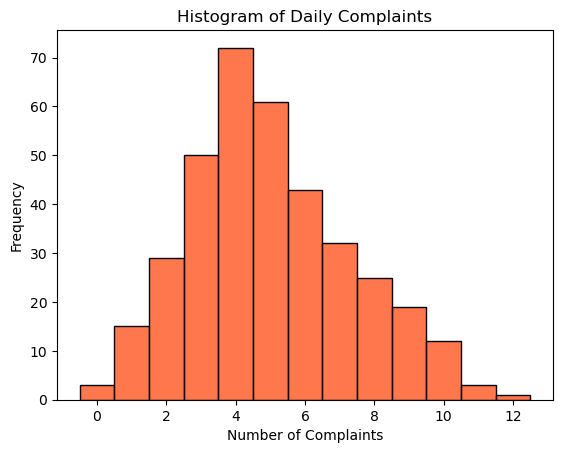

In [9]:
""" Histogram of Daily Complaints
Purpose:
The histogram provides a visual representation of the distribution of the number of customer complaints received each day over the past year.

Interpretation:

Shape of the Histogram:

The histogram should show the frequency of each count of complaints per day.
You should look for a pattern where most days have a similar number of complaints, with fewer days showing very high or very low counts.
Comparison to Poisson Distribution:

In a Poisson distribution, most of the data should cluster around the average number of complaints (λ). For this case, the average is set at 5 complaints per day.
The histogram should show a peak around this average and taper off as the number of complaints increases or decreases from this average.
"""
sns.histplot(df["complaints"], discrete=True, color='#ff4a11ff')
plt.title('Histogram of Daily Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Frequency')

In [40]:
"""Poisson Distribution PMF Plot
Purpose:

This plot shows the Probability Mass Function (PMF) of the Poisson distribution with a mean equal to the average number of 
complaints calculated from the data.


Interpretation:

Shape of the PMF Plot:

The PMF plot displays the probability of each possible number of complaints occurring, assuming a Poisson distribution with the calculated mean.
It should show probabilities decreasing as the number of complaints increases, with the highest probability at the average number of complaints.


Comparison to Histogram:

Compare the histogram of the data with the PMF plot.
If the histogram's shape closely matches the PMF plot, it suggests that the data follows a Poisson distribution well.
If there are significant deviations, it may indicate that the data does not perfectly follow a Poisson distribution. 
For example, if the variance is much different from the mean, or if the histogram does not align with the shape of the PMF plot, 
this would suggest that the Poisson model might not be a good fit.
"""

# Poisson Distribution Plot

#x = all possible values the random variable (complaints per day) can take.
x = np.arange(0, max(df["complaints"])+1) # the largest number of complaints we actually observed in the dataset.

#Why do we need it?
#Because when we plot the Poisson PMF (poisson.pmf(x, mean)), it requires us to specify which x-values we want probabilities for.

#Histogram: shows the observed counts.

#PMF: needs an explicit list of possible counts to compute probabilities.
#Without this line, SciPy wouldn’t know “which complaint counts” we want probabilities for — we have to give it the range.



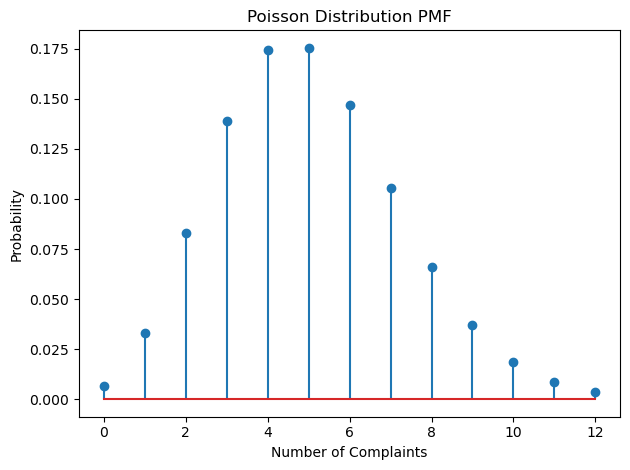

In [41]:
pmf = poisson.pmf(x, mean_complaints)
plt.stem(x, pmf) # stem plot
plt.title('Poisson Distribution PMF')
plt.xlabel('Number of Complaints')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

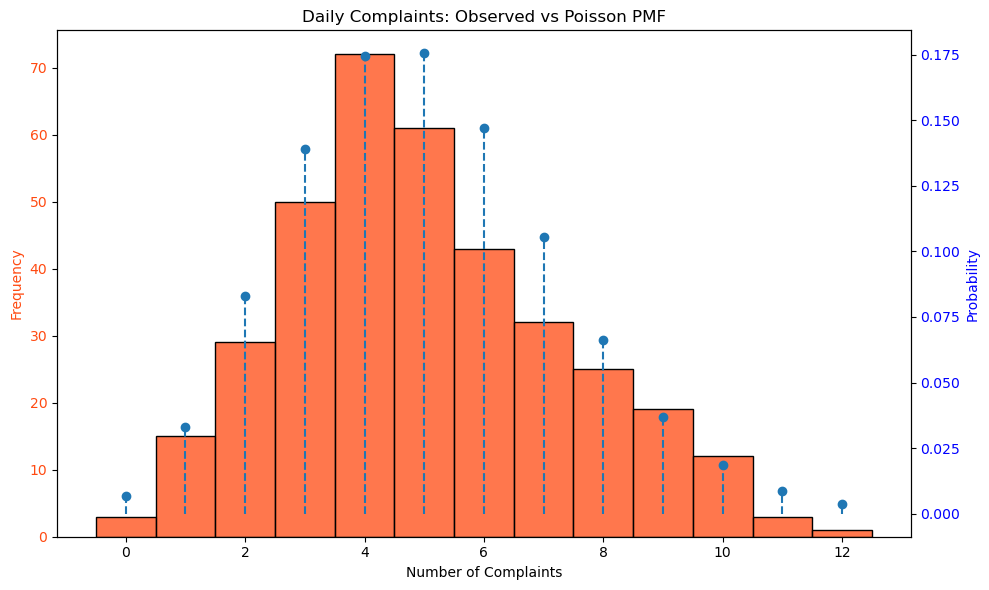

In [43]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Histogram (frequency)
sns.histplot(df["complaints"], discrete=True, color='#ff4a11ff', ax=ax1)
ax1.set_xlabel("Number of Complaints")
ax1.set_ylabel("Frequency", color='#ff4a11ff')
ax1.tick_params(axis='y', labelcolor='#ff4a11ff')

# PMF on secondary y-axis
ax2 = ax1.twinx()
ax2.stem(x, pmf, basefmt=" ", linefmt='--', markerfmt='o', label='Poisson PMF')
ax2.set_ylabel("Probability", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Daily Complaints: Observed vs Poisson PMF")
plt.tight_layout()
plt.show()

---


## Summary
This guide provides a structured approach to working with different types of data distributions. By following these steps, you can choose the right distribution, calculate relevant statistics, interpret data effectively, to ensure accurate analysis and conclusions.

---

# CASE STUDY- Quality Control in Manufacturing
We will now look at another scenario following a different type of distribution


Scenario: A manufacturing plant tracks the number of defective products in each batch. Each batch has 20 products. The company wants to understand the defect counts.


Hint: You can refer to the detailed overview steps from previous case study and also use the markdown file(it contains a summary of the steps and metrics to be calculated for the respective distributions). I will list the overview steps in order to not make it longer.

There is a section where you have to calculate the descriptive stats. 

1. Understand the Data Type: Continuous or discrete.

2. Identify the Analytical Question: Determine which distribution fits your question.

3. Calculate Descriptive Statistics: Compute and visualize summary statistics.

4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.


---

## Step 1: Understand the Data Type 



### Question: What type of data are we working with?

#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The data is discrete because it represents the count of defective products in each batch.</p>
  
</details>

---

## Step 2:  Identify the Analytical Question

### Question: What is the main question or goal for this analysis?

#### Your Answer here


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The goal is to determine if the number of defects per batch follows a Binomial distribution and to visualize this distribution.
</p>
  
</details>

--- 

## Step 3:  Calculate Descriptive Statistics

### Question: What descriptive statistics should we calculate for this data?
hint:  Refer to step 3 in the markdown file for distribution_functions


#### Your answer here: 


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Calculate the mean and variance of the number of defects per batch. For a Binomial distribution,
   the mean should be:

𝑛×𝑝

and the variance should be 

𝑛×𝑝×(1−𝑝)

, where 
𝑛 is the number of trials and 
𝑝 is the probability of defect.
</p>
  
</details>

--- 

## Step 4: Interpret the Graph and Descriptive Statistics

### Question: How can we interpret the histogram and the descriptive statistics?

#### Your Answer here

<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The histogram should show the count of defects per batch. If the data follows a Binomial distribution, the mean and variance should match the expected values from the distribution parameters.
</p>
  
</details>

In [16]:
# Generating the data, once again this is for the example you are not expected to know this.

from scipy.stats import binom # importing binom function since we are dealing with a success/failure scenario

df_defects = pd.read_csv("data/defects.csv")

In [17]:
df_defects.head()

,defects
0,2
1,3
2,0
3,1
4,1



Mean:The mean of the data should be close to  `𝑛×𝑝`

For this case, `𝑛=20` and `𝑝 is unknown`,

Calculate 𝑝 first:
- Estimate p from observed data

    - `p= Mean defects per batch ÷ batch size`

- Estimate p from observed data

    - `p_estimated = df_defects["defects"].mean() / n`

so the mean should be around  2(i.e., 20×0.1).

The calculated mean of the data from the sample should be compared to this expected value.


#### Additional Info! Not necessary to know 

**Variance:**
The variance of the data should be close to  `𝑛×𝑝×(1−𝑝)`

For this case, it should be around  1.8 (i.e., 20×0.1×0.9).

The calculated variance of the data should align with this expected variance.

In [35]:
# set the number of items per batch
n = 20

In [27]:
# calculate the descriptive stats
mean_defects = df_defects["defects"].mean()
variance_defects = df_defects["defects"].var()

In [20]:
# check the output
print(f" the mean number of defects are {mean_defects}")
print(f" the variance of defects are {variance_defects}")

 the mean number of defects are 2.02
 the variance of defects are 1.8985858585858615


In [29]:
# Calculate p for later 
# We don’t know the probability of a defect, so we estimate it from our observed data. 
# On average, each batch has X defects, and since there are n products, the probability of a defect is roughly
#  mean/n

p = mean_defects / 20
p

np.float64(0.101)

Text(0, 0.5, 'Frequency')

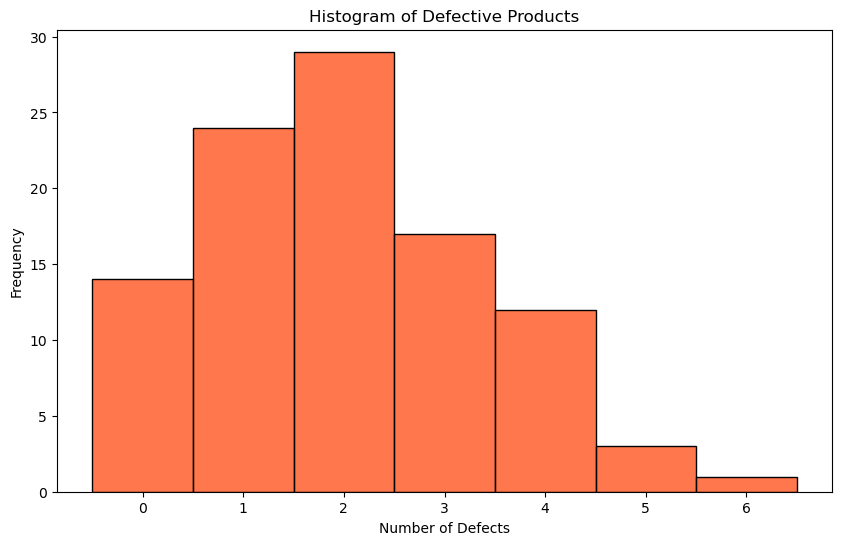

In [46]:
# Plotting
"""
Histogram of Defective Products
Purpose:

The histogram visualizes the distribution of the number of defective products in the batches.
Interpretation:

Shape of the Histogram:

The histogram should show the frequency of batches with a certain number of defective products. 
For example, it might show that most batches have a small number of defects, with fewer batches having higher numbers.
Since the data is generated using a binomial distribution with 
n=20 and p=0.1, 
you should expect to see a distribution where most values are concentrated around the lower end of the scale, 
with fewer batches showing higher defect counts.


Distribution Characteristics:


The histogram should reflect the properties of the Binomial distribution, 
where the number of defects typically falls within a limited range (0 to 20 in this case).
The shape should show a peak near the expected number of defects, 
with the frequency tapering off as the number of defects increases or decreases significantly from the mean.

"""

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_defects["defects"], discrete=True, color='#ff4a11ff')
plt.title('Histogram of Defective Products')
plt.xlabel('Number of Defects')
plt.ylabel('Frequency')

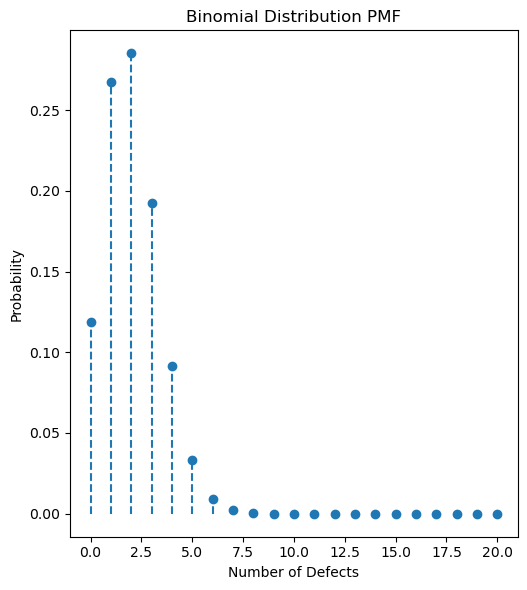

In [45]:
""" 
Binomial Distribution PMF Plot
Purpose:

This plot shows the Probability Mass Function (PMF) of the Binomial distribution with parameters 

n=20 and p=0.1.
Interpretation:

Shape of the PMF Plot:

The PMF plot displays the probability of each possible number of defects occurring in a batch.
You should see probabilities concentrated around a lower number of defects, 
consistent with a binomial distribution where the probability of defects is relatively low.
Comparison to Histogram:

Compare the histogram to the PMF plot to determine if the histogram’s shape matches the expected Binomial distribution.
If the histogram aligns well with the PMF plot, it suggests that the number of defects follows a Binomial distribution with the given parameters.
If there are significant discrepancies, such as a histogram showing a different shape or distribution than the PMF, 
this might indicate that the data does not follow a Binomial distribution as expected.

"""


# Binomial Distribution Plot
plt.figure(figsize=(10, 6))

x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)
plt.subplot(1, 2, 2)
plt.stem(x, pmf, basefmt=" ", linefmt='--', markerfmt='o')
plt.title('Binomial Distribution PMF')
plt.xlabel('Number of Defects')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

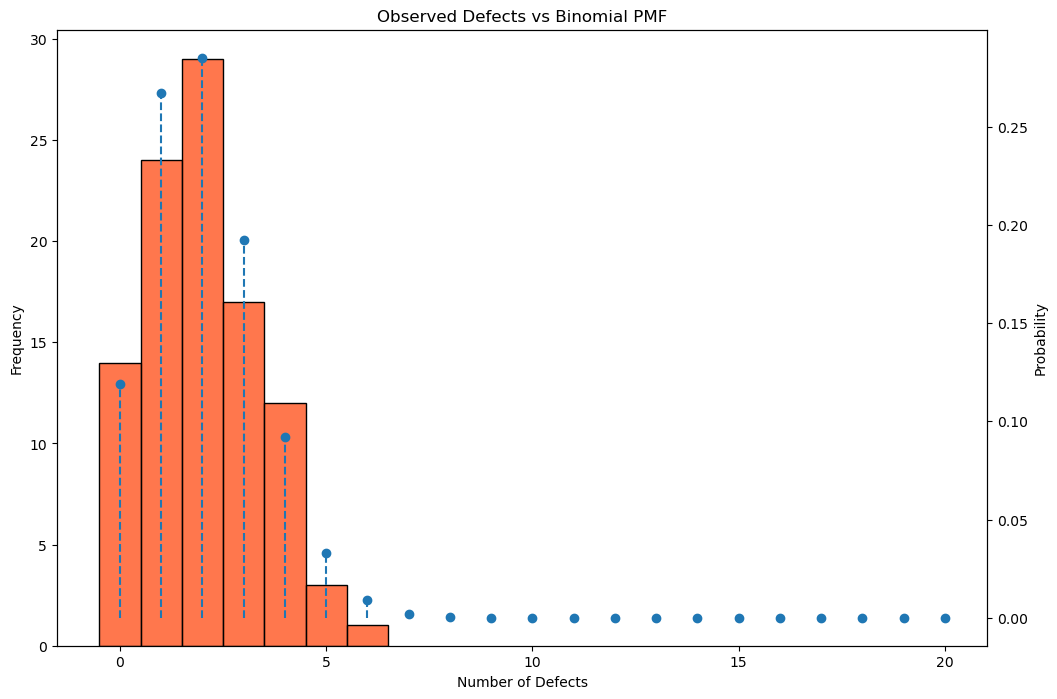

In [38]:
fig, ax1 = plt.subplots(figsize=(12,8))

# Histogram (frequency)
sns.histplot(df_defects["defects"], discrete=True, color='#ff4a11ff', ax=ax1)
ax1.set_xlabel("Number of Defects")
ax1.set_ylabel("Frequency")

# PMF on secondary y-axis
ax2 = ax1.twinx()
ax2.stem(x, pmf, basefmt=" ", linefmt='--', markerfmt='o')
ax2.set_ylabel("Probability")

plt.title("Observed Defects vs Binomial PMF")
plt.show()


## Summary

You should have a good overview of the steps involved when dealing with Poisson and Binomial Distribution. You have access to the markdown file which acts as a cheat sheet of sorts.

We will cover the remaining steps i.e. 5 to 7 when we explore Hypothesis testing.

Now its time to apply your new-found knowledge on a case study from scratch
